## Lecure traj 

In [11]:
# ============================================================
# CELL X — Chargement SBET entre deux timestamps
# ============================================================
import sys
import numpy as np

sys.path.append("/home/b085164/PDM_Romain_Defferrard/ESO-PDM")
from lib.trajectory import Trajectory

T_START = 316022.0
T_END   = 316095.0
T_GRID  = np.arange(T_START, T_END, 0.1)

SBET_CFG = {"type": "SBET", "timeRef": "GPS"}

SBET_PATH = "/media/b085164/Elements/ECCR/ODyN/base/out/ODyN_GNSS_INS.out"   # ← à adapter

print("Chargement SBET...")
trj = Trajectory.fromSBET(SBET_PATH, SBET_CFG)
trj.label = "SBET"
trj.interp(T_GRID, updateSelf=True)
trj.estimate_q_l2e(interp=True)
print("OK")

Chargement SBET...
Loading file /media/b085164/Elements/ECCR/ODyN/base/out/ODyN_GNSS_INS.out


OK


⚠️  Pas de sigma trouvé — fichier smrmsg nécessaire


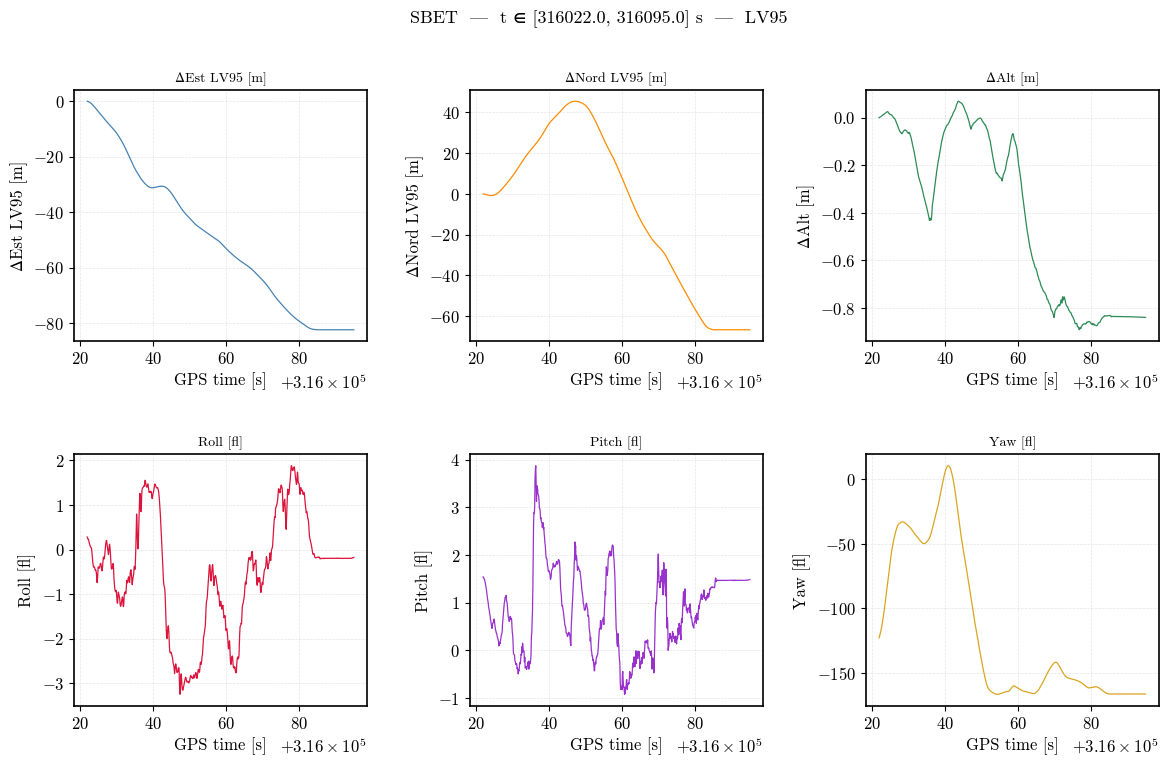

Échantillons dans [315645, 315658] : 2,600
Durée : 12.995 s
Fréquence moyenne : 200.0 Hz

              gx         gy         gz         ax         ay         az
count  2600.0000  2600.0000  2600.0000  2600.0000  2600.0000  2600.0000
mean      0.0013     0.0006     0.0901    -0.1600     0.0617     9.8180
std       0.0514     0.0542     0.0953     1.3924     0.7851     1.0902
min      -0.1983    -0.2473    -0.0630    -5.7504    -2.8346     3.6009
25%      -0.0262    -0.0273     0.0083    -0.9409    -0.4771     9.2029
50%       0.0020    -0.0031     0.0476    -0.1684     0.0755     9.7721
75%       0.0286     0.0257     0.1796     0.6529     0.5359    10.3224
max       0.1925     0.2631     0.2782     4.5292     3.0675    16.7747


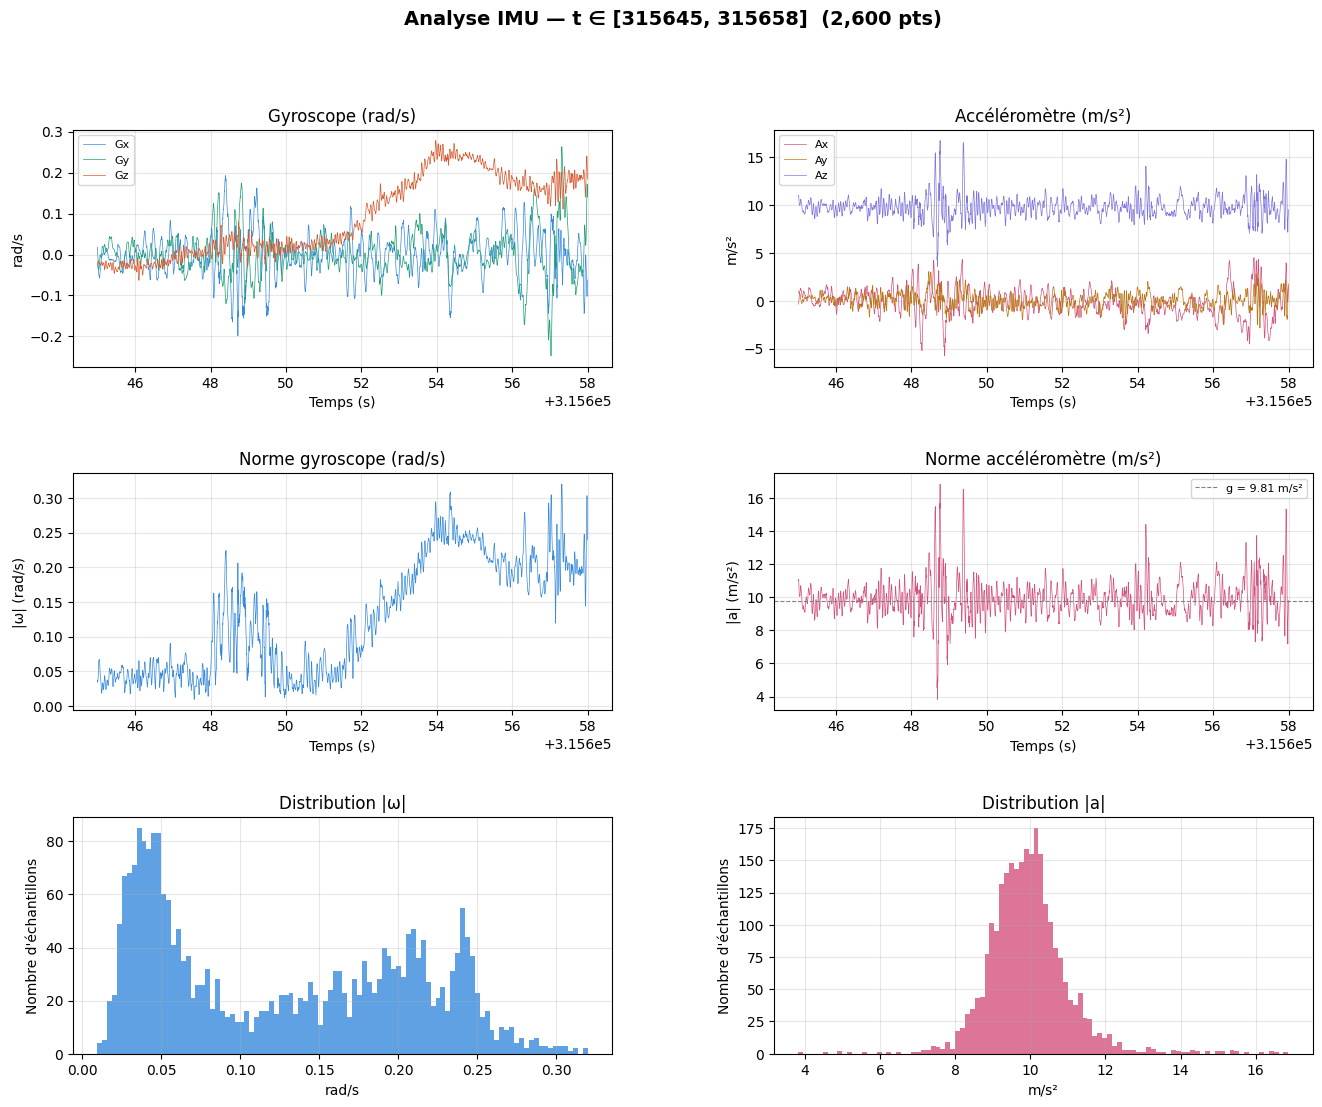


Pics gyro  (>0.371 rad/s)  : 0 échantillons
Pics accel (>13.220 m/s²)   : 35 échantillons


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 1. Chargement ──────────────────────────────────────────────────────────────
FILE_PATH = "/media/b085164/LaCie/2026spring_RD/ECCR/ODyN/Zone_1/outage/in/IMU.txt"
T_MIN, T_MAX = 315645, 315658

df = pd.read_csv(
    FILE_PATH,
    header=None,
    names=["t", "gx", "gy", "gz", "ax", "ay", "az"]
)

# ── 2. Filtrage sur la plage temporelle ────────────────────────────────────────
mask = (df["t"] >= T_MIN) & (df["t"] <= T_MAX)
df = df.loc[mask].reset_index(drop=True)
print(f"Échantillons dans [{T_MIN}, {T_MAX}] : {len(df):,}")
print(f"Durée : {df['t'].iloc[-1] - df['t'].iloc[0]:.3f} s")
print(f"Fréquence moyenne : {1 / df['t'].diff().median():.1f} Hz\n")

# ── 3. Statistiques descriptives ───────────────────────────────────────────────
print(df[["gx","gy","gz","ax","ay","az"]].describe().round(4))

# ── 4. Normes ──────────────────────────────────────────────────────────────────
df["gyro_norm"]  = np.sqrt(df.gx**2 + df.gy**2 + df.gz**2)
df["accel_norm"] = np.sqrt(df.ax**2 + df.ay**2 + df.az**2)

# ── 5. Visualisation ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 2, hspace=0.45, wspace=0.3)
t   = df["t"]

# Gyroscope X Y Z
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(t, df.gx, lw=0.5, label="Gx", color="#378ADD")
ax0.plot(t, df.gy, lw=0.5, label="Gy", color="#1D9E75")
ax0.plot(t, df.gz, lw=0.5, label="Gz", color="#D85A30")
ax0.set_title("Gyroscope (rad/s)")
ax0.set_xlabel("Temps (s)")
ax0.set_ylabel("rad/s")
ax0.legend(fontsize=8)
ax0.grid(True, alpha=0.3)

# Accéléromètre X Y Z
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(t, df.ax, lw=0.5, label="Ax", color="#D4537E")
ax1.plot(t, df.ay, lw=0.5, label="Ay", color="#BA7517")
ax1.plot(t, df.az, lw=0.5, label="Az", color="#7F77DD")
ax1.set_title("Accéléromètre (m/s²)")
ax1.set_xlabel("Temps (s)")
ax1.set_ylabel("m/s²")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Norme gyroscope
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(t, df.gyro_norm, lw=0.5, color="#378ADD")
ax2.set_title("Norme gyroscope (rad/s)")
ax2.set_xlabel("Temps (s)")
ax2.set_ylabel("|ω| (rad/s)")
ax2.grid(True, alpha=0.3)

# Norme accéléromètre
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(t, df.accel_norm, lw=0.5, color="#D4537E")
ax3.axhline(9.81, color="gray", ls="--", lw=0.8, label="g = 9.81 m/s²")
ax3.set_title("Norme accéléromètre (m/s²)")
ax3.set_xlabel("Temps (s)")
ax3.set_ylabel("|a| (m/s²)")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# Histogramme norme gyro
ax4 = fig.add_subplot(gs[2, 0])
ax4.hist(df.gyro_norm, bins=100, color="#378ADD", edgecolor="none", alpha=0.8)
ax4.set_title("Distribution |ω|")
ax4.set_xlabel("rad/s")
ax4.set_ylabel("Nombre d'échantillons")
ax4.grid(True, alpha=0.3)

# Histogramme norme accel
ax5 = fig.add_subplot(gs[2, 1])
ax5.hist(df.accel_norm, bins=100, color="#D4537E", edgecolor="none", alpha=0.8)
ax5.set_title("Distribution |a|")
ax5.set_xlabel("m/s²")
ax5.set_ylabel("Nombre d'échantillons")
ax5.grid(True, alpha=0.3)

fig.suptitle(f"Analyse IMU — t ∈ [{T_MIN}, {T_MAX}]  ({len(df):,} pts)",
             fontsize=14, fontweight="bold")
plt.show()

# ── 6. Détection des pics dynamiques (µ + 3σ) ─────────────────────────────────
SEUIL_GYRO  = df.gyro_norm.mean()  + 3 * df.gyro_norm.std()
SEUIL_ACCEL = df.accel_norm.mean() + 3 * df.accel_norm.std()

pics_gyro  = df[df.gyro_norm  > SEUIL_GYRO]
pics_accel = df[df.accel_norm > SEUIL_ACCEL]

print(f"\nPics gyro  (>{SEUIL_GYRO:.3f} rad/s)  : {len(pics_gyro):,} échantillons")
print(f"Pics accel (>{SEUIL_ACCEL:.3f} m/s²)   : {len(pics_accel):,} échantillons")

## Extraction polygone pour limatch

In [6]:
from pathlib import Path
import numpy as np
import laspy
from shapely.geometry import Polygon, Point

# ============================================================
# INPUT
# ============================================================
las1_path = Path("/media/b085164/LaCie/2026spring_RD/ECCR/georef_VUX_zone_3_outage/HA/260225_154000_VUX-HA1_pcd.las")  # à adapter
las2_path = Path("/media/b085164/LaCie/2026spring_RD/ECCR/georef_VUX_zone_3_outage/HA/260225_154111_VUX-HA1_pcd.las")  # à adapter
out_dir   = Path("/media/b085164/LaCie/2026spring_RD/ECCR/georef_VUX_zone_3_outage/cropped")
out_dir.mkdir(parents=True, exist_ok=True)

# 4 coins du polygone en LV95 (XY uniquement)
POLYGON_XY = [
    (2533279.279999, 1155071.776000),
    (2533248.285995, 1155080.875977), 
    (2533261.567993, 1155109.391968),
    (2533293.871002, 1155095.176025), 
]

# ============================================================
# BUILD POLYGON
# ============================================================
poly = Polygon(POLYGON_XY)
print(f"Polygone area : {poly.area:.1f} m²")

# ============================================================
# CROP FUNCTION
# ============================================================
def crop_las_by_polygon(las_path: Path, polygon: Polygon, out_path: Path, chunk_size: int = 2_000_000):
    print(f"\n{'='*60}")
    print(f"  Input  : {las_path.name}")
    print(f"  Output : {out_path.name}")

    # Bbox pre-filter
    minx, miny, maxx, maxy = polygon.bounds

    kept_points = []

    with laspy.open(las_path) as reader:
        total = reader.header.point_count
        kept  = 0

        for points in reader.chunk_iterator(chunk_size):
            x = np.asarray(points.x, dtype=np.float64)
            y = np.asarray(points.y, dtype=np.float64)

            # Bbox pre-filter (fast)
            bbox_mask = (x >= minx) & (x <= maxx) & (y >= miny) & (y <= maxy)
            if not np.any(bbox_mask):
                continue

            # Exact polygon test on bbox survivors
            x_b = x[bbox_mask]
            y_b = y[bbox_mask]

            poly_mask = np.array([
                polygon.contains(Point(xi, yi))
                for xi, yi in zip(x_b, y_b)
            ])

            final_mask = np.zeros(len(x), dtype=bool)
            idx = np.where(bbox_mask)[0]
            final_mask[idx[poly_mask]] = True

            if np.any(final_mask):
                kept_points.append(points[final_mask])
                kept += int(final_mask.sum())

        print(f"  Points kept : {kept:,} / {total:,} ({100*kept/total:.2f} %)")

    if not kept_points:
        print("  -> aucun point dans le polygone")
        return

    # Write output
    with laspy.open(las_path) as reader:
        header = reader.header

    with laspy.open(out_path, mode="w", header=header) as writer:
        for pts in kept_points:
            writer.write_points(pts)

    print(f"  -> écrit : {out_path}")

# ============================================================
# RUN
# ============================================================
crop_las_by_polygon(las1_path, poly, out_dir / f"{las1_path.stem}_crop.las")
crop_las_by_polygon(las2_path, poly, out_dir / f"{las2_path.stem}_crop.las")

print("\nTerminé.")

Polygone area : 984.0 m²

  Input  : 260225_154000_VUX-HA1_pcd.las
  Output : 260225_154000_VUX-HA1_pcd_crop.las
  Points kept : 3,519,945 / 22,683,413 (15.52 %)
  -> écrit : /media/b085164/LaCie/2026spring_RD/ECCR/georef_VUX_zone_3_outage/cropped/260225_154000_VUX-HA1_pcd_crop.las

  Input  : 260225_154111_VUX-HA1_pcd.las
  Output : 260225_154111_VUX-HA1_pcd_crop.las
  Points kept : 3,944,625 / 16,365,467 (24.10 %)
  -> écrit : /media/b085164/LaCie/2026spring_RD/ECCR/georef_VUX_zone_3_outage/cropped/260225_154111_VUX-HA1_pcd_crop.las

Terminé.
